Importing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('DSNY_Monthly_Tonnage_Data_20251117.csv')

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24647 entries, 0 to 24646
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MONTH                24647 non-null  object 
 1   BOROUGH              24647 non-null  object 
 2   COMMUNITYDISTRICT    24647 non-null  int64  
 3   REFUSETONSCOLLECTED  24647 non-null  float64
 4   PAPERTONSCOLLECTED   22213 non-null  float64
 5   MGPTONSCOLLECTED     22570 non-null  float64
 6   RESORGANICSTONS      3095 non-null   float64
 7   SCHOOLORGANICTONS    2308 non-null   float64
 8   LEAVESORGANICTONS    881 non-null    object 
 9   XMASTREETONS         1685 non-null   float64
 10  OTHERORGANICSTONS    1933 non-null   float64
 11  BOROUGH_ID           24647 non-null  int64  
dtypes: float64(7), int64(2), object(3)
memory usage: 2.3+ MB


,MONTH,BOROUGH,COMMUNITYDISTRICT,REFUSETONSCOLLECTED,PAPERTONSCOLLECTED,MGPTONSCOLLECTED,RESORGANICSTONS,SCHOOLORGANICTONS,LEAVESORGANICTONS,XMASTREETONS,OTHERORGANICSTONS,BOROUGH_ID
0,2025 / 10,Bronx,1,3352.0,235.0,124.8,16.7,85.9,NaN,NaN,NaN,2
1,2025 / 10,Bronx,2,7942.4,231.6,213.8,20.4,100.7,NaN,NaN,NaN,2
2,2025 / 10,Bronx,3,2348.6,140.1,147.5,19.1,NaN,NaN,NaN,NaN,2
3,2025 / 10,Bronx,4,4210.4,233.3,291.1,20.8,70.7,NaN,NaN,0.3,2
4,2025 / 10,Bronx,5,3578.3,216.6,299.9,17.1,85.6,NaN,NaN,NaN,2


In [ ]:
pop_df = pd.read_csv('New_York_City_Population_By_Community_Districts_20251123.csv')
pop_df.head()

,Borough,CD Number,CD Name,1970 Population,1980 Population,1990 Population,2000 Population,2010 Population
0,Bronx,1,"Melrose, Mott Haven, Port Morris","138,557","78,441","77,214","82,159","91,497"
1,Bronx,2,"Hunts Point, Longwood","99,493","34,399","39,443","46,824","52,246"
2,Bronx,3,"Morrisania, Crotona Park East","150,636","53,635","57,162","68,574","79,762"
3,Bronx,4,"Highbridge, Concourse Village","144,207","114,312","119,962","139,563","146,441"
4,Bronx,5,"University Hts., Fordham, Mt. Hope","121,807","107,995","118,435","128,313","128,200"


Data processing


In [ ]:
# Only filter for 2024 trash data
df['MONTH'] = pd.to_datetime(df['MONTH'], format='%Y / %m')
df_2024 = df[df['MONTH'].dt.year == 2024]

In [ ]:
# Rename the columns in pop_df for merging
pop_df = pop_df.rename(columns={'CD Number': 'COMMUNITYDISTRICT', 'Borough': 'BOROUGH'})
# Only include 2010 Population column
pop_df = pop_df[['BOROUGH', 'COMMUNITYDISTRICT', '2010 Population']]

Analyses

In [ ]:
# Per capita: “Tons of Refuse” per 1,000 Residents in 59 community districts
refuse_tonnage_2024_by_district = df_2024.groupby(['BOROUGH', 'COMMUNITYDISTRICT'])['REFUSETONSCOLLECTED'].mean().round()

print("Average monthly trash (in tons) collected for each community district in 2024:")
print(refuse_tonnage_2024_by_district.head())

Average monthly trash (in tons) collected for each community district in 2024:
BOROUGH  COMMUNITYDISTRICT
Bronx    1                    3284.0
         2                    7837.0
         3                    2206.0
         4                    4039.0
         5                    3456.0
Name: REFUSETONSCOLLECTED, dtype: float64


In [ ]:
merged_df = pd.merge(refuse_tonnage_2024_by_district, pop_df, on=['BOROUGH', 'COMMUNITYDISTRICT'], how='inner')
merged_df['District'] = merged_df['BOROUGH'] + ' District ' + merged_df['COMMUNITYDISTRICT'].astype(str)
merged_df.head()

,BOROUGH,COMMUNITYDISTRICT,REFUSETONSCOLLECTED,2010 Population,District
0,Bronx,1,3284.0,"91,497",Bronx District 1
1,Bronx,2,7837.0,"52,246",Bronx District 2
2,Bronx,3,2206.0,"79,762",Bronx District 3
3,Bronx,4,4039.0,"146,441",Bronx District 4
4,Bronx,5,3456.0,"128,200",Bronx District 5


## Part 1: Analysis based on REFUSETONSCOLLECTED

### Average Monthly Refuse Tonnage per Borough (2024)

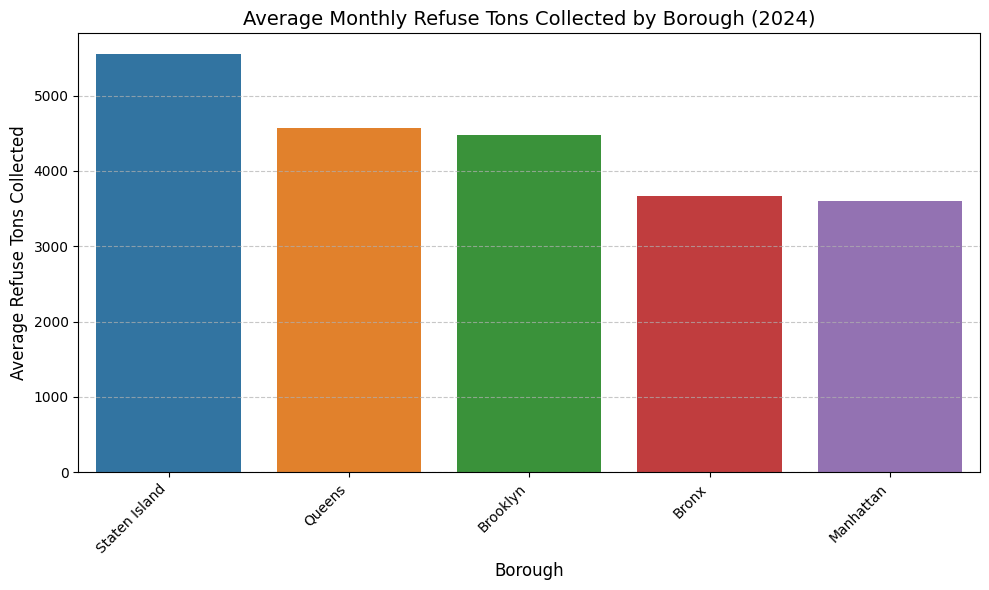

In [ ]:
# Calculate average monthly refuse tonnage for each borough
borough_avg_refuse_tons = df_2024.groupby('BOROUGH')['REFUSETONSCOLLECTED'].mean().round(2)
borough_avg_refuse_tons_df = borough_avg_refuse_tons.reset_index()

# Sort from most to least
borough_avg_refuse_tons_df = borough_avg_refuse_tons_df.sort_values(by='REFUSETONSCOLLECTED', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='BOROUGH', y='REFUSETONSCOLLECTED', data=borough_avg_refuse_tons_df, hue='BOROUGH', legend=False)
plt.title('Average Monthly Refuse Tons Collected by Borough (2024)', fontsize=14)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Average Refuse Tons Collected', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Top 10 Community Districts by Refuse Tons Collected (2024)

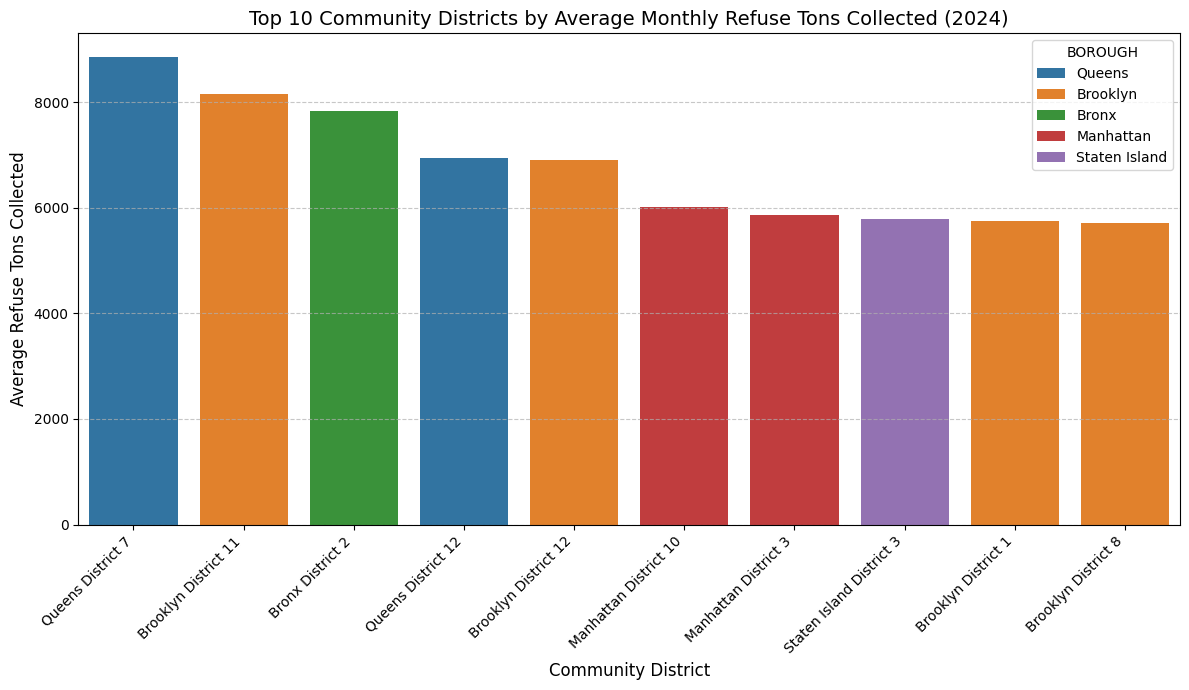

In [ ]:
# The 'refuse_tonnage_2024_by_district' variable already contains the average monthly REFUSETONSCOLLECTED per district.
top_10_districts_by_refuse = refuse_tonnage_2024_by_district.reset_index().sort_values(by='REFUSETONSCOLLECTED', ascending=False).head(10)

# Create a 'District' column for better labeling on the plot
top_10_districts_by_refuse['District'] = top_10_districts_by_refuse['BOROUGH'] + ' District ' + top_10_districts_by_refuse['COMMUNITYDISTRICT'].astype(str)

plt.figure(figsize=(12, 7))
sns.barplot(x='District', y='REFUSETONSCOLLECTED', data=top_10_districts_by_refuse, hue='BOROUGH', dodge=False)
plt.title('Top 10 Community Districts by Average Monthly Refuse Tons Collected (2024)', fontsize=14)
plt.xlabel('Community District', fontsize=12)
plt.ylabel('Average Refuse Tons Collected', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Heatmap of Average Monthly Refuse Tons Collected by Borough and Community District (2024)

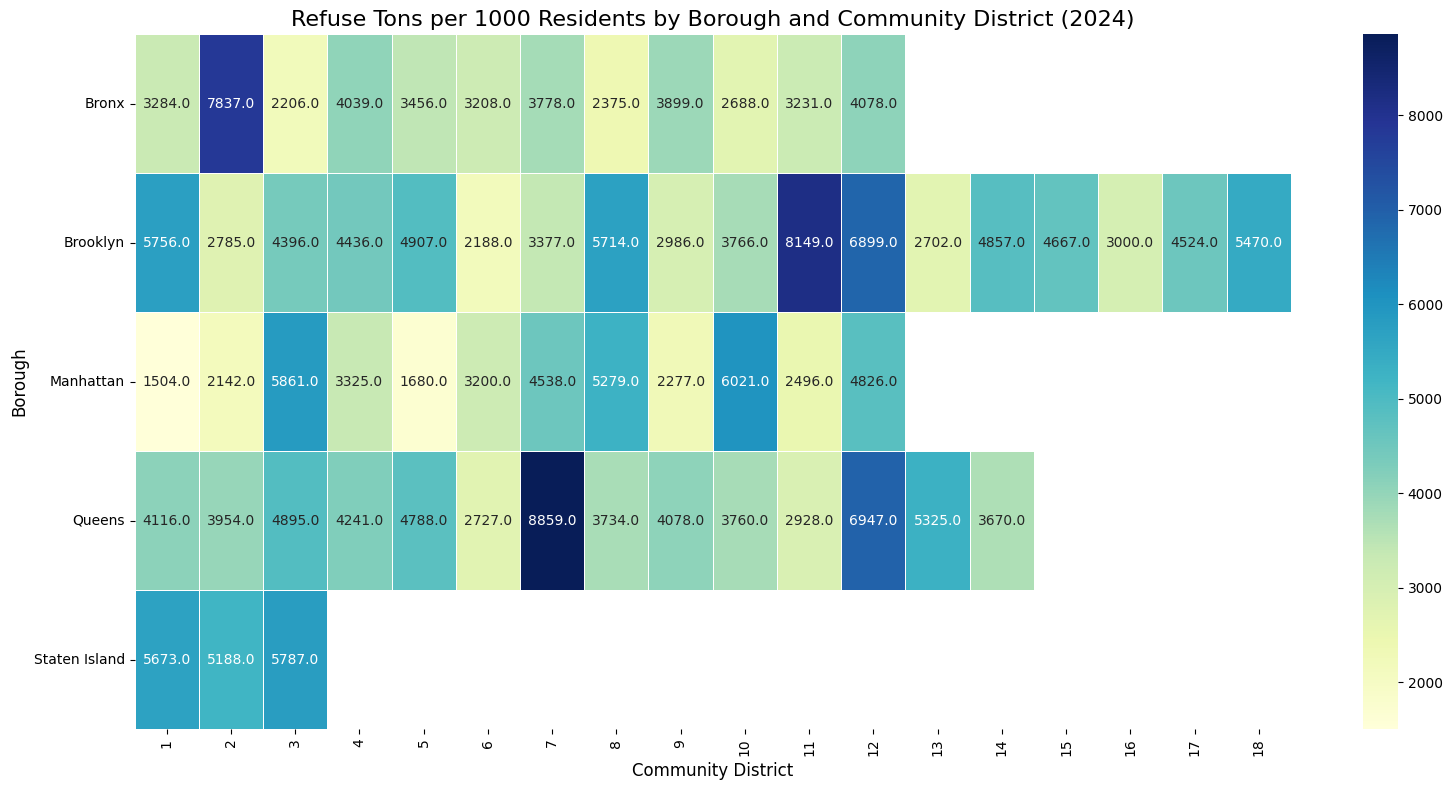

In [ ]:
heatmap_data_refuse = refuse_tonnage_2024_by_district.unstack(level='COMMUNITYDISTRICT').fillna(0)

plt.figure(figsize=(16, 8))
mask = heatmap_data_refuse == 0
sns.heatmap(heatmap_data_refuse, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5, mask=mask)
plt.title('Refuse Tons per 1000 Residents by Borough and Community District (2024)', fontsize=16)
plt.xlabel('Community District', fontsize=12)
plt.ylabel('Borough', fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

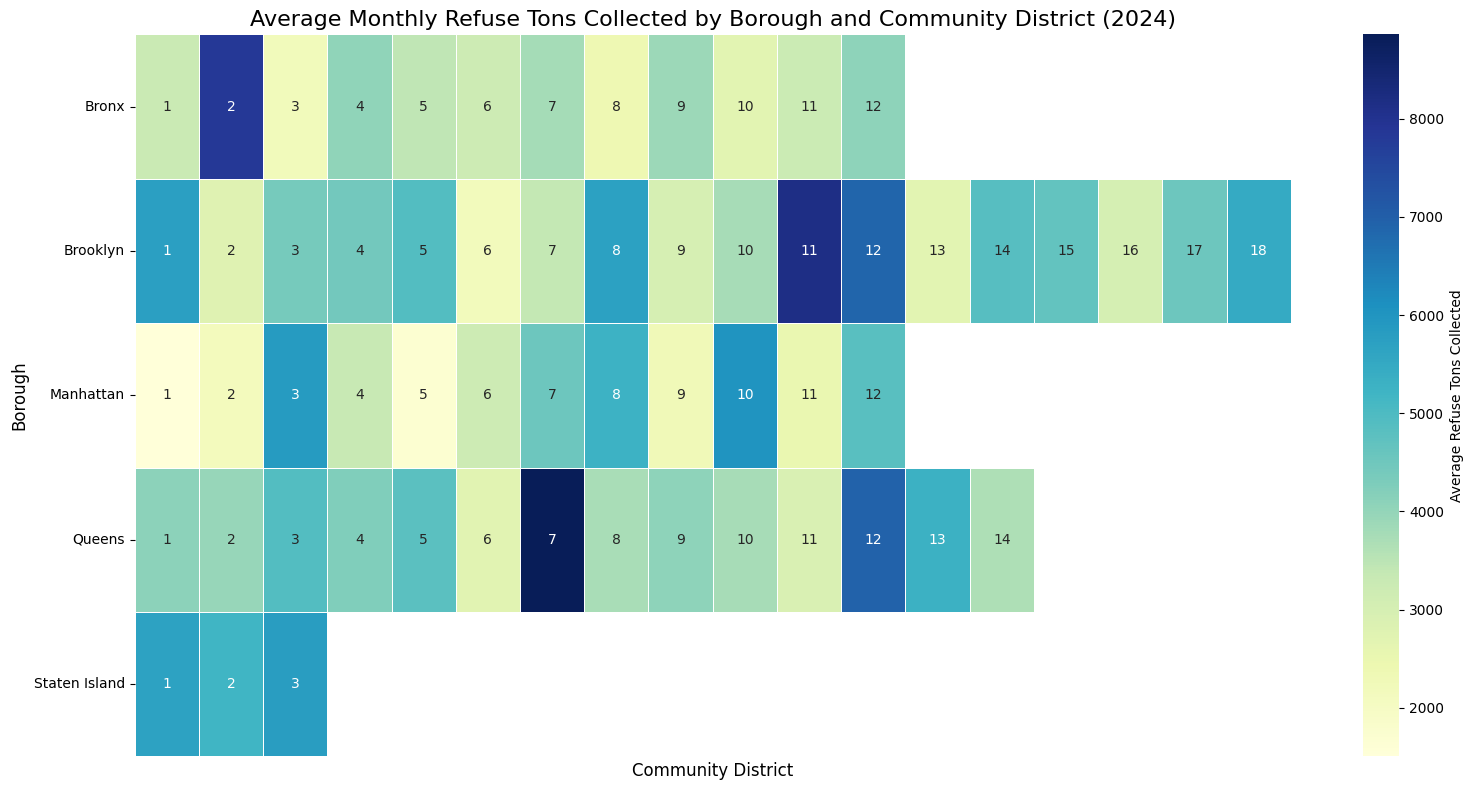

In [ ]:
merged_df_for_annotations_refuse = refuse_tonnage_2024_by_district.reset_index().copy()
merged_df_for_annotations_refuse['CD_VALUE'] = merged_df_for_annotations_refuse['COMMUNITYDISTRICT']
cd_annotations_refuse = merged_df_for_annotations_refuse.pivot_table(index='BOROUGH', columns='COMMUNITYDISTRICT', values='CD_VALUE', aggfunc='first').fillna('')

plt.figure(figsize=(16, 8))
mask_refuse = heatmap_data_refuse == 0
sns.heatmap(heatmap_data_refuse, annot=cd_annotations_refuse, fmt=".0f", cmap="YlGnBu", linewidths=.5, mask=mask_refuse, cbar_kws={'label': 'Average Refuse Tons Collected'})
plt.title('Average Monthly Refuse Tons Collected by Borough and Community District (2024)', fontsize=16)
plt.xlabel('Community District', fontsize=12)
plt.ylabel('Borough', fontsize=12)
plt.xticks([]) # Hide x-axis ticks to show only CD numbers as annotations
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Part 2: Analysis based on Refuse Tons per 1000 Residents

In [ ]:
merged_df['Refuse Tons per 1000 Residents'] = (merged_df['REFUSETONSCOLLECTED'] / merged_df['2010 Population']) * 1000
merged_df.head()

,BOROUGH,COMMUNITYDISTRICT,REFUSETONSCOLLECTED,2010 Population,District,Refuse Tons per 1000 Residents
0,Bronx,1,3284.0,91497,Bronx District 1,35.891887
1,Bronx,2,7837.0,52246,Bronx District 2,150.001914
2,Bronx,3,2206.0,79762,Bronx District 3,27.657280
3,Bronx,4,4039.0,146441,Bronx District 4,27.581074
4,Bronx,5,3456.0,128200,Bronx District 5,26.957878


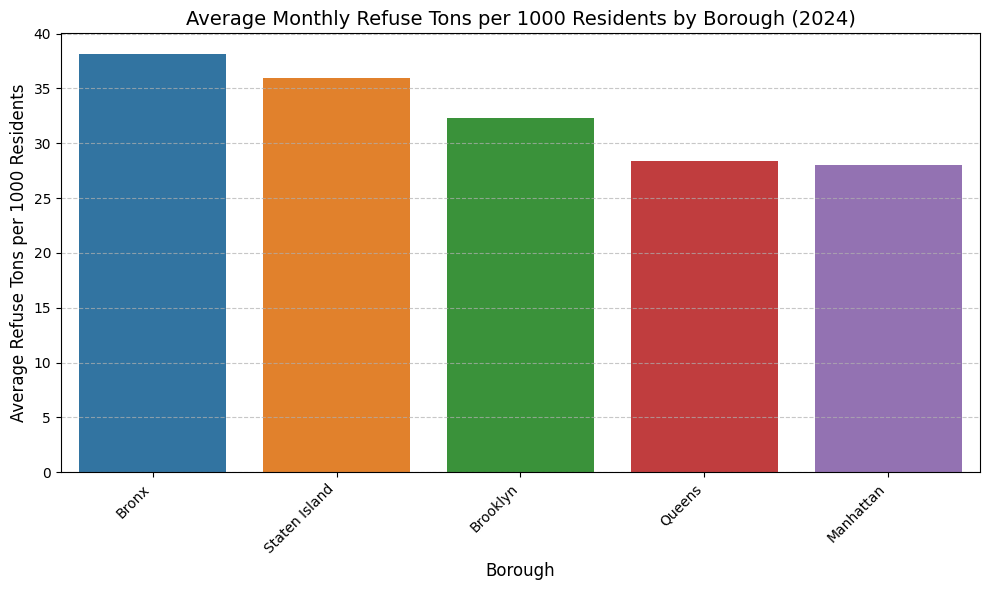

In [ ]:
# Average monthly tonnage for each borough bar plot
borough_avg_refuse_per_resident = merged_df.groupby('BOROUGH')['Refuse Tons per 1000 Residents'].mean().round(2)
borough_avg_refuse_df = borough_avg_refuse_per_resident.reset_index()

# Sort from most to least
borough_avg_refuse_df = borough_avg_refuse_df.sort_values(by='Refuse Tons per 1000 Residents', ascending=False)

plt.figure(figsize=(10, 6))
# Color palette
sns.barplot(x='BOROUGH', y='Refuse Tons per 1000 Residents', data=borough_avg_refuse_df, hue='BOROUGH', legend=False)
plt.title('Average Monthly Refuse Tons per 1000 Residents by Borough (2024)', fontsize=14)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Average Refuse Tons per 1000 Residents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

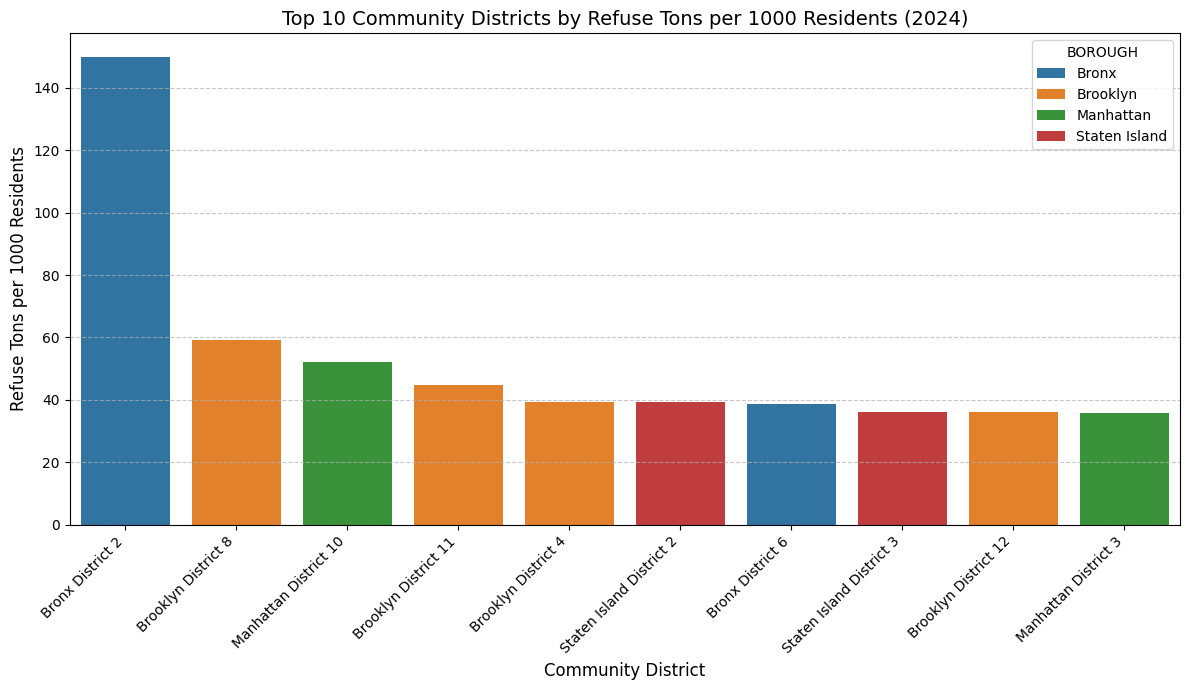

In [ ]:
top_residents_refuse = merged_df.sort_values(by='Refuse Tons per 1000 Residents', ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x='District', y='Refuse Tons per 1000 Residents', data=top_residents_refuse, hue='BOROUGH', dodge=False)
plt.title('Top 10 Community Districts by Refuse Tons per 1000 Residents (2024)', fontsize=14)
plt.xlabel('Community District', fontsize=12)
plt.ylabel('Refuse Tons per 1000 Residents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Heat Map

In [ ]:
heatmap_data = merged_df.pivot_table(index='BOROUGH', columns='COMMUNITYDISTRICT', values='Refuse Tons per 1000 Residents').fillna(0)
heatmap_data.head()

COMMUNITYDISTRICT,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
BOROUGH,,,,,,,,,,,,,,,,,,
Bronx,35.891887,150.001914,27.657280,27.581074,26.957878,38.526205,27.124047,23.345883,22.629398,22.327065,28.534337,26.768366,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Brooklyn,33.255721,27.957076,28.734843,39.384200,26.829455,20.896007,26.752753,59.324937,30.336588,30.251183,44.779400,36.048322,25.911506,30.230792,29.232697,34.694916,29.139721,28.262453
Manhattan,24.664633,23.795770,35.896054,32.204949,32.512144,22.417598,21.704195,24.004183,20.663745,52.029415,20.711802,25.397327,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Queens,21.537898,34.929329,28.529631,24.571548,28.299545,24.077982,35.815067,24.710966,28.454405,30.719958,25.147942,30.749959,28.235406,31.919150,0.000000,0.000000,0.000000,0.000000
Staten Island,32.277703,39.302137,36.121566,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


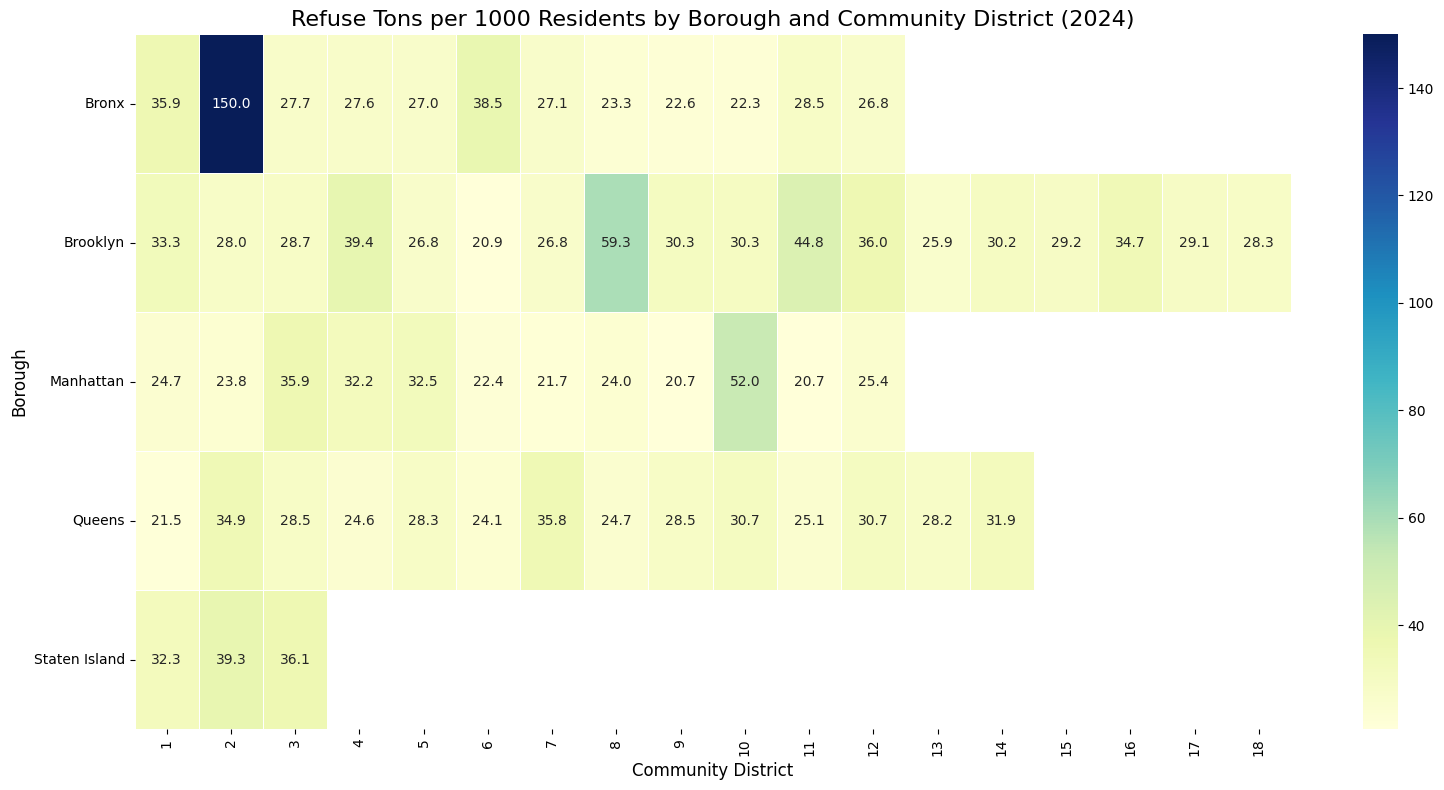

In [ ]:
plt.figure(figsize=(16, 8))
mask = heatmap_data == 0
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5, mask=mask)
plt.title('Refuse Tons per 1000 Residents by Borough and Community District (2024)', fontsize=16)
plt.xlabel('Community District', fontsize=12)
plt.ylabel('Borough', fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

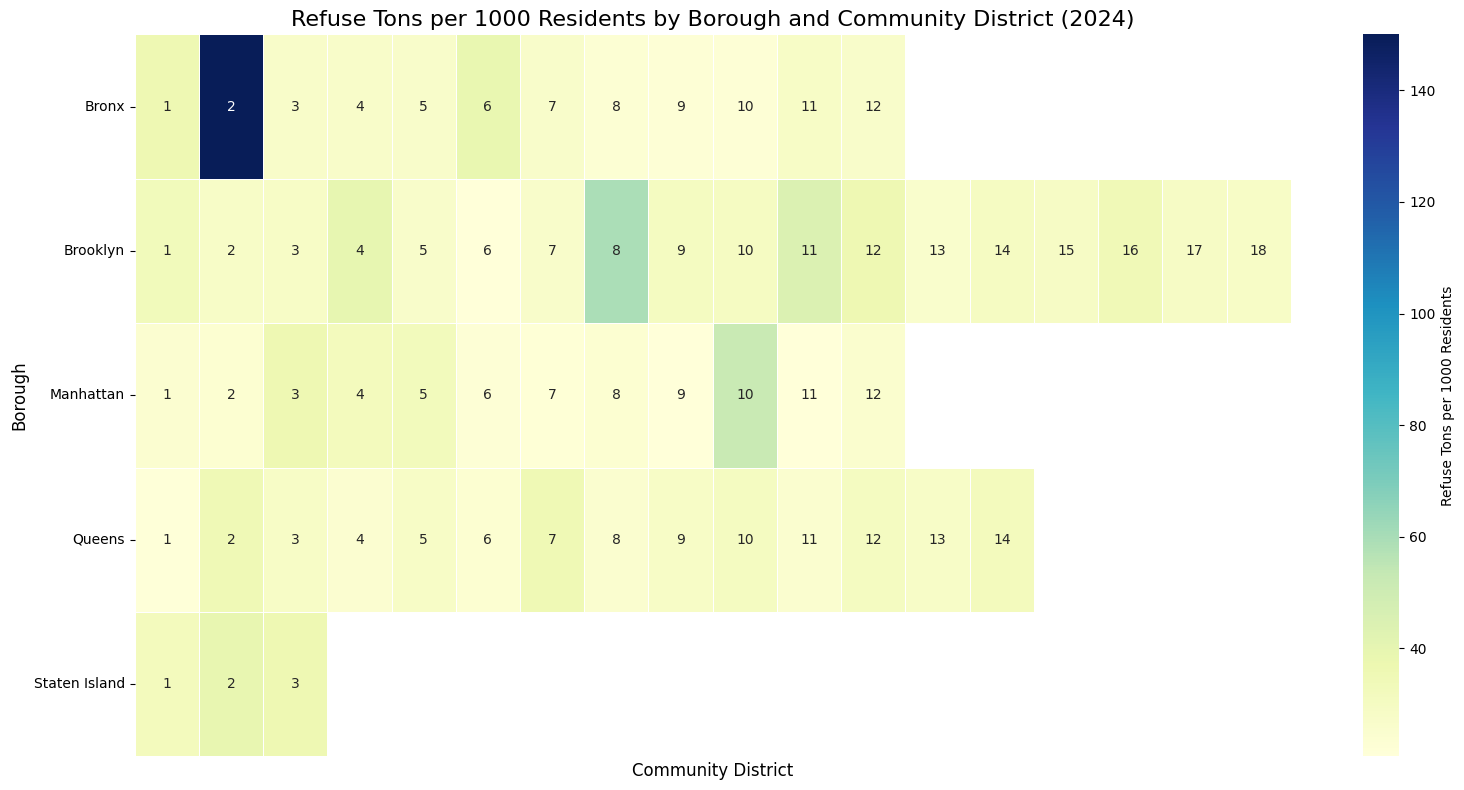

In [ ]:
merged_df_for_annotations = merged_df.copy()
merged_df_for_annotations['CD_VALUE'] = merged_df_for_annotations['COMMUNITYDISTRICT']
cd_annotations = merged_df_for_annotations.pivot_table(index='BOROUGH', columns='COMMUNITYDISTRICT', values='CD_VALUE', aggfunc='first').fillna('')

plt.figure(figsize=(16, 8))
mask = heatmap_data == 0
sns.heatmap(heatmap_data, annot=cd_annotations, fmt=".0f", cmap="YlGnBu", linewidths=.5, mask=mask, cbar_kws={'label': 'Refuse Tons per 1000 Residents'})
plt.title('Refuse Tons per 1000 Residents by Borough and Community District (2024)', fontsize=16)
plt.xlabel('Community District', fontsize=12)
plt.ylabel('Borough', fontsize=12)
plt.xticks([])
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Part 3: Trend of the highest tonnage community districts in the last 10 years.

In [ ]:
# Filter df for bronx, district 2 from 2014 january to 2024 december
# Group by on this df by averaging the month per year

bronx_district2_df = df[(df['BOROUGH'] == 'Bronx') & (df['COMMUNITYDISTRICT'] == 2)].copy()
bronx_district2_df_filtered_years = bronx_district2_df[(bronx_district2_df['MONTH'].dt.year >= 2014) & (bronx_district2_df['MONTH'].dt.year <= 2024)].copy()
bronx_district2_df_filtered_years['YEAR'] = bronx_district2_df_filtered_years['MONTH'].dt.year
bronx_district2_refuse_yearly = bronx_district2_df_filtered_years.groupby('YEAR')['REFUSETONSCOLLECTED'].mean().reset_index()

bronx_district2_refuse_yearly.head()

,YEAR,REFUSETONSCOLLECTED
0,2014,7991.400000
1,2015,8047.975000
2,2016,8262.991667
3,2017,8213.100000
4,2018,8471.866667


In [ ]:
# Filter pop_df for bronx, district 2

bronx_district2_pop = pop_df[(pop_df['BOROUGH'] == 'Bronx') & (pop_df['COMMUNITYDISTRICT'] == 2)]
print("Population data for Bronx, District 2:")
print(bronx_district2_pop.head())

Population data for Bronx, District 2:
  BOROUGH  COMMUNITYDISTRICT 2010 Population
1   Bronx                  2          52,246


In [ ]:
# Merge them
# Calculate the Refuse Tons per 1000 Residents

bronx_district2_pop_value = float(bronx_district2_pop['2010 Population'].str.replace(',', '').iloc[0])
bronx_district2_refuse_yearly['2010 Population'] = bronx_district2_pop_value
bronx_district2_refuse_yearly['Refuse Tons per 1000 Residents'] = (bronx_district2_refuse_yearly['REFUSETONSCOLLECTED'] / bronx_district2_refuse_yearly['2010 Population']) * 1000
print("Yearly 'Refuse Tons per 1000 Residents' for Bronx, District 2 (2014-2024):")
print(bronx_district2_refuse_yearly.head())

Yearly 'Refuse Tons per 1000 Residents' for Bronx, District 2 (2014-2024):
   YEAR  REFUSETONSCOLLECTED  2010 Population  Refuse Tons per 1000 Residents
0  2014          7991.400000          52246.0                      152.957164
1  2015          8047.975000          52246.0                      154.040022
2  2016          8262.991667          52246.0                      158.155489
3  2017          8213.100000          52246.0                      157.200551
4  2018          8471.866667          52246.0                      162.153402


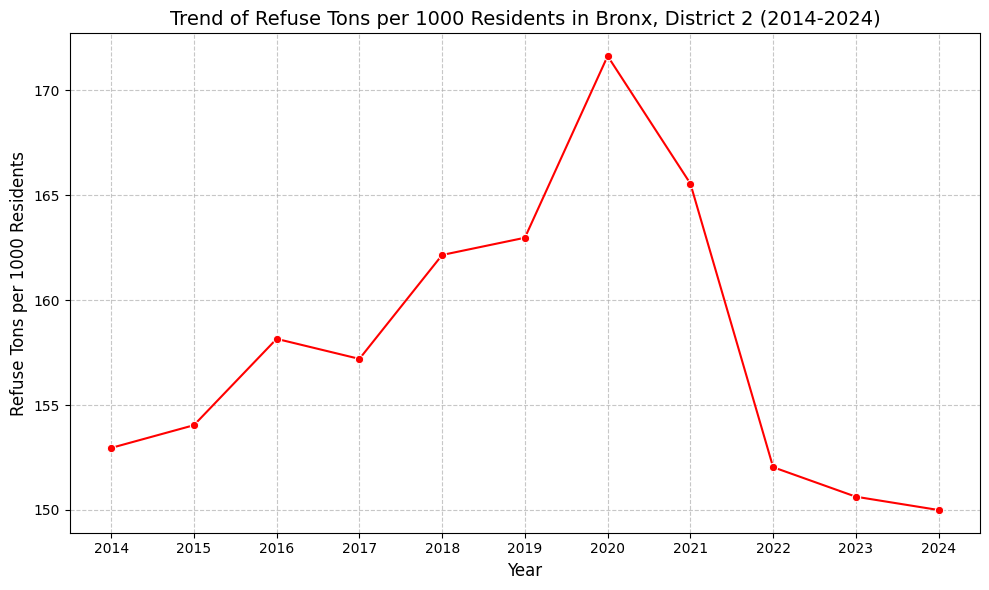

In [ ]:
# Line graph of the last 10 years, Refuse Tons per 1000 for each year

plt.figure(figsize=(10, 6))
sns.lineplot(x='YEAR', y='Refuse Tons per 1000 Residents', data=bronx_district2_refuse_yearly, marker='o', color='red')
plt.title('Trend of Refuse Tons per 1000 Residents in Bronx, District 2 (2014-2024)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Refuse Tons per 1000 Residents', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(bronx_district2_refuse_yearly['YEAR'].unique())
plt.tight_layout()
plt.show()